# 06 Train Improved WLASL300 Model — BiGRU + Attention V2

## Purpose

This notebook improves the current WLASL300 model before scaling to WLASL1000.

Current WLASL300 V1 result:

```text
Test Top-1 Accuracy: 35.44%
Test Top-3 Accuracy: 58.48%
Test Top-5 Accuracy: 67.09%
Test Macro F1: 29.69%
```

## V2 improvement strategy

This notebook keeps the best architecture direction from WLASL100 and WLASL300, but improves it with:

- keypoints + velocity + acceleration features
- stronger BiGRU hidden size
- attention pooling + mean pooling + max pooling
- light data augmentation
- balanced class sampling
- AdamW optimiser
- learning-rate scheduling
- gradient clipping
- early stopping
- comparison with the previous WLASL300 V1 result

## Expected input

Run these notebooks before this one:

```text
01_inspect_wlasl300_dataset.ipynb
02_extract_wlasl300_keypoints.ipynb
03_check_wlasl300_keypoints.ipynb
04_train_wlasl300_bigru_attention.ipynb
05_evaluate_wlasl300_bigru_attention.ipynb
```

Required file:

```text
data/processed/ASL/WLASL300/wlasl300_clean_keypoint_index.csv
```

In [2]:
from pathlib import Path
import json
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score

warnings.filterwarnings("ignore", category=UserWarning)

## 1. Set project paths and training settings

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path("E:/Be_My_Ear")

DATASET_NAME = "WLASL300"
PREFIX = "wlasl300"

BASE_DIR = PROJECT_ROOT / "data" / "processed" / "ASL" / DATASET_NAME
CLEAN_INDEX_FILE = BASE_DIR / f"{PREFIX}_clean_keypoint_index.csv"

LABEL_MAP_FILE = PROJECT_ROOT / "data" / "label_maps" / DATASET_NAME / f"asl_{PREFIX}_labels.json"

MODEL_DIR = PROJECT_ROOT / "models" / "ASL" / DATASET_NAME
MODEL_DIR.mkdir(parents=True, exist_ok=True)

REPORT_DIR = PROJECT_ROOT / "reports" / f"phase1_{PREFIX}"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / f"bigru_attention_v2_{PREFIX}.pt"
HISTORY_PATH = MODEL_DIR / f"bigru_attention_v2_{PREFIX}_history.csv"
NORM_STATS_PATH = MODEL_DIR / f"{PREFIX}_v2_train_norm_stats.npz"
RESULT_FILE = MODEL_DIR / f"bigru_attention_v2_{PREFIX}_result_summary.csv"

BATCH_SIZE = 24
EPOCHS = 80
EARLY_STOPPING_PATIENCE = 18

USE_VELOCITY = True
USE_ACCELERATION = True

ORIGINAL_FEATURE_SIZE = 258
INPUT_SIZE = ORIGINAL_FEATURE_SIZE * 3
SEQUENCE_LENGTH = 60

HIDDEN_SIZE = 384
NUM_LAYERS = 3
DROPOUT = 0.35

print("Dataset:", DATASET_NAME)
print("Clean index exists:", CLEAN_INDEX_FILE.exists())
print("Label map exists:", LABEL_MAP_FILE.exists())
print("Model will save to:", MODEL_PATH)
print("Report folder:", REPORT_DIR)

Dataset: WLASL300
Clean index exists: True
Label map exists: True
Model will save to: E:\Be_My_Ear\models\ASL\WLASL300\bigru_attention_v2_wlasl300.pt
Report folder: E:\Be_My_Ear\reports\phase1_wlasl300


## 2. Load clean WLASL300 keypoint index

In [4]:
df = pd.read_csv(CLEAN_INDEX_FILE)

print("Clean samples:", len(df))
print("Classes:", df["label_id"].nunique())
print("Example keypoint path:", df.iloc[0]["keypoint_path"])

df.head()

Clean samples: 2660
Classes: 300
Example keypoint path: E:\Be_My_Ear\data\processed\ASL\WLASL300\keypoints\65096.npy


,video_id,gloss,label_id,original_class_id,video_path,keypoint_path,zero_ratio
0,65096,arrive,10,182,E:\Be_My_Ear\data\raw\ASL\videos\65096.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL300\keypo...,0.236047
1,65639,environment,107,279,E:\Be_My_Ear\data\raw\ASL\videos\65639.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL300\keypo...,0.227907
2,10112,chat,53,191,E:\Be_My_Ear\data\raw\ASL\videos\10112.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL300\keypo...,0.028876
3,55348,student,253,247,E:\Be_My_Ear\data\raw\ASL\videos\55348.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL300\keypo...,0.297093
4,65092,argue,9,258,E:\Be_My_Ear\data\raw\ASL\videos\65092.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL300\keypo...,0.244186


## 3. Create train / validation / test split

The split logic matches the earlier WLASL300 notebook so V1 and V2 are comparable.

In [5]:
train_records = []
val_records = []
test_records = []

for label_id, group in df.groupby("label_id"):
    group = group.sample(frac=1, random_state=SEED).reset_index(drop=True)

    n = len(group)
    n_test = max(1, int(round(n * 0.15)))
    n_val = max(1, int(round(n * 0.15)))

    test_records.append(group.iloc[:n_test])
    val_records.append(group.iloc[n_test:n_test + n_val])
    train_records.append(group.iloc[n_test + n_val:])

train_df = pd.concat(train_records).sample(frac=1, random_state=SEED).reset_index(drop=True)
val_df = pd.concat(val_records).sample(frac=1, random_state=SEED).reset_index(drop=True)
test_df = pd.concat(test_records).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))
print("Train classes:", train_df["label_id"].nunique())
print("Validation classes:", val_df["label_id"].nunique())
print("Test classes:", test_df["label_id"].nunique())

Train samples: 1870
Validation samples: 395
Test samples: 395
Train classes: 300
Validation classes: 300
Test classes: 300


## 4. Compute normalisation statistics from training data only

In [6]:
def compute_train_normalisation_stats(train_dataframe):
    total_sum = None
    total_sq_sum = None
    total_count = 0

    for path in tqdm(train_dataframe["keypoint_path"], desc="Computing train mean/std"):
        arr = np.load(path).astype(np.float32)

        if total_sum is None:
            total_sum = arr.sum(axis=0)
            total_sq_sum = (arr ** 2).sum(axis=0)
        else:
            total_sum += arr.sum(axis=0)
            total_sq_sum += (arr ** 2).sum(axis=0)

        total_count += arr.shape[0]

    mean = total_sum / total_count
    variance = (total_sq_sum / total_count) - (mean ** 2)
    variance = np.maximum(variance, 1e-6)
    std = np.sqrt(variance)

    return mean.astype(np.float32), std.astype(np.float32)


train_mean, train_std = compute_train_normalisation_stats(train_df)
np.savez(NORM_STATS_PATH, mean=train_mean, std=train_std)

print("Saved normalisation stats:", NORM_STATS_PATH)
print("Mean shape:", train_mean.shape)
print("Std shape:", train_std.shape)

Computing train mean/std: 100%|██████████| 1870/1870 [00:02<00:00, 803.33it/s]

Saved normalisation stats: E:\Be_My_Ear\models\ASL\WLASL300\wlasl300_v2_train_norm_stats.npz
Mean shape: (258,)
Std shape: (258,)


## 5. Dataset with keypoints + velocity + acceleration

V1 input:

```text
keypoints + velocity = 516 features
```

V2 input:

```text
keypoints + velocity + acceleration = 774 features
```

Acceleration helps the model understand how motion changes across frames.

In [7]:
class WLASL300V2Dataset(Dataset):
    def __init__(
        self,
        dataframe,
        mean,
        std,
        augment=False,
        noise_std=0.01,
        frame_mask_prob=0.05
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.mean = mean.reshape(1, -1).astype(np.float32)
        self.std = std.reshape(1, -1).astype(np.float32)
        self.augment = augment
        self.noise_std = noise_std
        self.frame_mask_prob = frame_mask_prob

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        keypoints = np.load(row["keypoint_path"]).astype(np.float32)
        keypoints = (keypoints - self.mean) / (self.std + 1e-6)

        velocity = np.zeros_like(keypoints, dtype=np.float32)
        velocity[1:] = keypoints[1:] - keypoints[:-1]

        acceleration = np.zeros_like(keypoints, dtype=np.float32)
        acceleration[1:] = velocity[1:] - velocity[:-1]

        features = np.concatenate([keypoints, velocity, acceleration], axis=1).astype(np.float32)

        if self.augment:
            if self.noise_std > 0:
                features += np.random.normal(0, self.noise_std, features.shape).astype(np.float32)

            if self.frame_mask_prob > 0:
                frame_mask = np.random.rand(features.shape[0]) < self.frame_mask_prob
                features[frame_mask] = 0

        label = int(row["label_id"])

        return torch.tensor(features, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

## 6. Create balanced data loaders

In [8]:
train_dataset = WLASL300V2Dataset(train_df, train_mean, train_std, augment=True)
val_dataset = WLASL300V2Dataset(val_df, train_mean, train_std, augment=False)
test_dataset = WLASL300V2Dataset(test_df, train_mean, train_std, augment=False)

class_counts = train_df["label_id"].value_counts().sort_index().to_dict()

sample_weights = train_df["label_id"].map(lambda label: 1.0 / class_counts[label]).values
sample_weights = torch.DoubleTensor(sample_weights)

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

x_batch, y_batch = next(iter(train_loader))

print("Input batch shape:", x_batch.shape)
print("Label batch shape:", y_batch.shape)
print("Input feature size:", INPUT_SIZE)

Input batch shape: torch.Size([24, 60, 774])
Label batch shape: torch.Size([24])
Input feature size: 774


## 7. Define BiGRU + Multi-Pooling Attention V2

V1 used mainly attention context. V2 combines:

- attention pooling
- mean pooling
- max pooling

This gives the classifier more information about the whole sign sequence.

In [9]:
class BiGRUAttentionV2(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size,
        num_classes,
        num_layers=3,
        dropout=0.35
    ):
        super().__init__()

        self.input_projection = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.gru = nn.GRU(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        bi_hidden = hidden_size * 2

        self.attention = nn.Sequential(
            nn.Linear(bi_hidden, hidden_size),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1)
        )

        classifier_input_size = bi_hidden * 3

        self.classifier = nn.Sequential(
            nn.Linear(classifier_input_size, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.input_projection(x)

        gru_out, _ = self.gru(x)

        attention_scores = self.attention(gru_out).squeeze(-1)
        attention_weights = torch.softmax(attention_scores, dim=1).unsqueeze(-1)

        attention_context = torch.sum(gru_out * attention_weights, dim=1)
        mean_context = torch.mean(gru_out, dim=1)
        max_context, _ = torch.max(gru_out, dim=1)

        combined = torch.cat([attention_context, mean_context, max_context], dim=1)

        return self.classifier(combined)

## 8. Initialise model, optimiser, and scheduler

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

NUM_CLASSES = df["label_id"].nunique()

model = BiGRUAttentionV2(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_classes=NUM_CLASSES,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Number of classes:", NUM_CLASSES)
print("Input size:", INPUT_SIZE)
print("Hidden size:", HIDDEN_SIZE)
print("GRU layers:", NUM_LAYERS)
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Using device: cpu
Number of classes: 300
Input size: 774
Hidden size: 384
GRU layers: 3
Total parameters: 9075885
Trainable parameters: 9075885


## 9. Training helpers

In [11]:
def top_k_accuracy(outputs, labels, k=5):
    _, top_k_preds = outputs.topk(k, dim=1)
    correct = top_k_preds.eq(labels.view(-1, 1).expand_as(top_k_preds))
    return correct.any(dim=1).float().mean().item()


def run_epoch(model, loader, optimizer=None, phase="Train", epoch=1, total_epochs=1):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0
    total_top1 = 0
    total_top3 = 0
    total_top5 = 0

    all_preds = []
    all_labels = []

    progress_bar = tqdm(loader, desc=f"Epoch {epoch}/{total_epochs} [{phase}]", leave=False)

    with torch.set_grad_enabled(is_train):
        for step, (x, y) in enumerate(progress_bar, start=1):
            x = x.to(device)
            y = y.to(device)

            if is_train:
                optimizer.zero_grad()

            outputs = model(x)
            loss = criterion(outputs, y)

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            preds = torch.argmax(outputs, dim=1)

            batch_top1 = (preds == y).float().mean().item()
            batch_top3 = top_k_accuracy(outputs, y, k=3)
            batch_top5 = top_k_accuracy(outputs, y, k=5)

            total_loss += loss.item()
            total_top1 += batch_top1
            total_top3 += batch_top3
            total_top5 += batch_top5

            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(y.detach().cpu().numpy())

            progress_bar.set_postfix({
                "step": f"{step}/{len(loader)}",
                "loss": f"{loss.item():.4f}",
                "top1": f"{batch_top1:.4f}",
                "top5": f"{batch_top5:.4f}",
                "lr": f"{optimizer.param_groups[0]['lr']:.6f}" if optimizer else "-"
            })

    avg_loss = total_loss / len(loader)
    avg_top1 = total_top1 / len(loader)
    avg_top3 = total_top3 / len(loader)
    avg_top5 = total_top5 / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return avg_loss, avg_top1, avg_top3, avg_top5, macro_f1

## 10. Train V2 model

This trains up to 80 epochs, but early stopping will stop earlier if validation Macro F1 does not improve.

In [12]:
history = {
    "train_loss": [],
    "train_top1": [],
    "train_top3": [],
    "train_top5": [],
    "train_f1": [],
    "val_loss": [],
    "val_top1": [],
    "val_top3": [],
    "val_top5": [],
    "val_f1": [],
    "lr": []
}

best_val_f1 = 0.0
best_val_top5 = 0.0
epochs_without_improvement = 0

print("=" * 80)
print("Be My Ear - WLASL300 BiGRU + Attention V2 Training")
print("=" * 80)
print(f"Device: {device}")
print(f"Input shape: (60, {INPUT_SIZE})")
print(f"Classes: {NUM_CLASSES}")
print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Model save path: {MODEL_PATH}")
print("=" * 80)

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    print("-" * 80)

    train_loss, train_top1, train_top3, train_top5, train_f1 = run_epoch(
        model, train_loader, optimizer=optimizer, phase="Training", epoch=epoch, total_epochs=EPOCHS
    )

    val_loss, val_top1, val_top3, val_top5, val_f1 = run_epoch(
        model, val_loader, optimizer=None, phase="Validation", epoch=epoch, total_epochs=EPOCHS
    )

    scheduler.step(val_f1)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_top1"].append(train_top1)
    history["train_top3"].append(train_top3)
    history["train_top5"].append(train_top5)
    history["train_f1"].append(train_f1)

    history["val_loss"].append(val_loss)
    history["val_top1"].append(val_top1)
    history["val_top3"].append(val_top3)
    history["val_top5"].append(val_top5)
    history["val_f1"].append(val_f1)
    history["lr"].append(current_lr)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_val_top5 = val_top5
        epochs_without_improvement = 0

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_f1": best_val_f1,
            "best_val_top5": best_val_top5,
            "num_classes": NUM_CLASSES,
            "input_size": INPUT_SIZE,
            "sequence_length": SEQUENCE_LENGTH,
            "use_velocity": USE_VELOCITY,
            "use_acceleration": USE_ACCELERATION,
            "architecture": "BiGRUAttentionV2",
            "hidden_size": HIDDEN_SIZE,
            "num_layers": NUM_LAYERS,
            "dropout": DROPOUT
        }, MODEL_PATH)

        save_status = "Saved new best model"
    else:
        epochs_without_improvement += 1
        save_status = "No improvement"

    print(f"Train | Loss: {train_loss:.4f} | Top-1: {train_top1:.4f} | Top-3: {train_top3:.4f} | Top-5: {train_top5:.4f} | F1: {train_f1:.4f}")
    print(f"Val   | Loss: {val_loss:.4f} | Top-1: {val_top1:.4f} | Top-3: {val_top3:.4f} | Top-5: {val_top5:.4f} | F1: {val_f1:.4f}")
    print(f"Learning rate: {current_lr:.8f}")
    print(f"Status: {save_status}")
    print(f"Best Val F1 so far: {best_val_f1:.4f}")
    print(f"Best Val Top-5 so far: {best_val_top5:.4f}")
    print(f"Epochs without improvement: {epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}")

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("\nEarly stopping triggered.")
        break

training_minutes = (time.time() - start_time) / 60

print("\n" + "=" * 80)
print("V2 training completed")
print("=" * 80)
print(f"Total training time: {training_minutes:.2f} minutes")
print(f"Best validation F1: {best_val_f1:.4f}")
print(f"Best validation Top-5: {best_val_top5:.4f}")
print(f"Best model saved to: {MODEL_PATH}")
print("=" * 80)

Be My Ear - WLASL300 BiGRU + Attention V2 Training
Device: cpu
Input shape: (60, 774)
Classes: 300
Train samples: 1870
Validation samples: 395
Test samples: 395
Epochs: 80
Batch size: 24
Model save path: E:\Be_My_Ear\models\ASL\WLASL300\bigru_attention_v2_wlasl300.pt

Epoch 1/80
--------------------------------------------------------------------------------


Train | Loss: 5.7374 | Top-1: 0.0059 | Top-3: 0.0134 | Top-5: 0.0230 | F1: 0.0020
Val   | Loss: 5.5866 | Top-1: 0.0049 | Top-3: 0.0254 | Top-5: 0.0475 | F1: 0.0001
Learning rate: 0.00020000
Status: Saved new best model
Best Val F1 so far: 0.0001
Best Val Top-5 so far: 0.0475
Epochs without improvement: 0/18

Epoch 2/80
--------------------------------------------------------------------------------


Train | Loss: 5.5592 | Top-1: 0.0112 | Top-3: 0.0299 | Top-5: 0.0481 | F1: 0.0065
Val   | Loss: 5.4619 | Top-1: 0.0147 | Top-3: 0.0397 | Top-5: 0.0544 | F1: 0.0033
Learning rate: 0.00020000
Status: Saved new best model
Best Val F1 so far: 0.0033
Best Val Top-5 so far: 0.0544
Epochs without improvement: 0/18

Epoch 3/80
--------------------------------------------------------------------------------


Train | Loss: 5.3710 | Top-1: 0.0193 | Top-3: 0.0455 | Top-5: 0.0711 | F1: 0.0068
Val   | Loss: 5.3020 | Top-1: 0.0245 | Top-3: 0.0515 | Top-5: 0.0764 | F1: 0.0044
Learning rate: 0.00020000
Status: Saved new best model
Best Val F1 so far: 0.0044
Best Val Top-5 so far: 0.0764
Epochs without improvement: 0/18

Epoch 4/80
--------------------------------------------------------------------------------


Train | Loss: 5.2152 | Top-1: 0.0241 | Top-3: 0.0626 | Top-5: 0.0985 | F1: 0.0115
Val   | Loss: 5.1861 | Top-1: 0.0270 | Top-3: 0.0490 | Top-5: 0.0760 | F1: 0.0045
Learning rate: 0.00020000
Status: Saved new best model
Best Val F1 so far: 0.0045
Best Val Top-5 so far: 0.0760
Epochs without improvement: 0/18

Epoch 5/80
--------------------------------------------------------------------------------


...

Train | Loss: 0.6327 | Top-1: 0.9957 | Top-3: 1.0000 | Top-5: 1.0000 | F1: 0.9954
Val   | Loss: 3.6413 | Top-1: 0.3536 | Top-3: 0.5325 | Top-5: 0.5992 | F1: 0.2847
Learning rate: 0.00005000
Status: No improvement
Best Val F1 so far: 0.2907
Best Val Top-5 so far: 0.5844
Epochs without improvement: 14/18

Epoch 60/80
--------------------------------------------------------------------------------


Train | Loss: 0.6366 | Top-1: 0.9909 | Top-3: 1.0000 | Top-5: 1.0000 | F1: 0.9902
Val   | Loss: 3.6329 | Top-1: 0.3360 | Top-3: 0.5276 | Top-5: 0.6065 | F1: 0.2787
Learning rate: 0.00005000
Status: No improvement
Best Val F1 so far: 0.2907
Best Val Top-5 so far: 0.5844
Epochs without improvement: 15/18

Epoch 61/80
--------------------------------------------------------------------------------


Train | Loss: 0.6265 | Top-1: 0.9952 | Top-3: 1.0000 | Top-5: 1.0000 | F1: 0.9947
Val   | Loss: 3.5969 | Top-1: 0.3336 | Top-3: 0.5399 | Top-5: 0.6012 | F1: 0.2725
Learning rate: 0.00005000
Status: No improvement
Best Val F1 so far: 0.2907
Best Val Top-5 so far: 0.5844
Epochs without improvement: 16/18

Epoch 62/80
--------------------------------------------------------------------------------


Train | Loss: 0.6247 | Top-1: 0.9952 | Top-3: 1.0000 | Top-5: 1.0000 | F1: 0.9948
Val   | Loss: 3.6312 | Top-1: 0.3385 | Top-3: 0.5301 | Top-5: 0.6065 | F1: 0.2823
Learning rate: 0.00005000
Status: No improvement
Best Val F1 so far: 0.2907
Best Val Top-5 so far: 0.5844
Epochs without improvement: 17/18

Epoch 63/80
--------------------------------------------------------------------------------


Train | Loss: 0.6316 | Top-1: 0.9915 | Top-3: 1.0000 | Top-5: 1.0000 | F1: 0.9911
Val   | Loss: 3.6233 | Top-1: 0.3262 | Top-3: 0.5325 | Top-5: 0.6065 | F1: 0.2663
Learning rate: 0.00002500
Status: No improvement
Best Val F1 so far: 0.2907
Best Val Top-5 so far: 0.5844
Epochs without improvement: 18/18

Early stopping triggered.

V2 training completed
Total training time: 113.76 minutes
Best validation F1: 0.2907
Best validation Top-5: 0.5844
Best model saved to: E:\Be_My_Ear\models\ASL\WLASL300\bigru_attention_v2_wlasl300.pt


## 11. Save training history and plot curves

In [13]:
history_df = pd.DataFrame(history)
history_df.to_csv(HISTORY_PATH, index=False)

print("Saved training history to:", HISTORY_PATH)
history_df.head()

Saved training history to: E:\Be_My_Ear\models\ASL\WLASL300\bigru_attention_v2_wlasl300_history.csv


,train_loss,train_top1,train_top3,train_top5,train_f1,val_loss,val_top1,val_top3,val_top5,val_f1,lr
0,5.737374,0.005876,0.013355,0.022970,0.002039,5.586640,0.004902,0.025401,0.047460,0.000074,0.0002
1,5.559150,0.011218,0.029915,0.048077,0.006526,5.461934,0.014706,0.039661,0.054367,0.003299,0.0002
2,5.371029,0.019279,0.045503,0.071144,0.006835,5.301985,0.024510,0.051471,0.076426,0.004362,0.0002
3,5.215242,0.024136,0.062646,0.098485,0.011503,5.186095,0.026961,0.049020,0.075980,0.004542,0.0002
4,5.106299,0.037927,0.083430,0.119318,0.019887,5.066654,0.022504,0.066622,0.103387,0.008162,0.0002


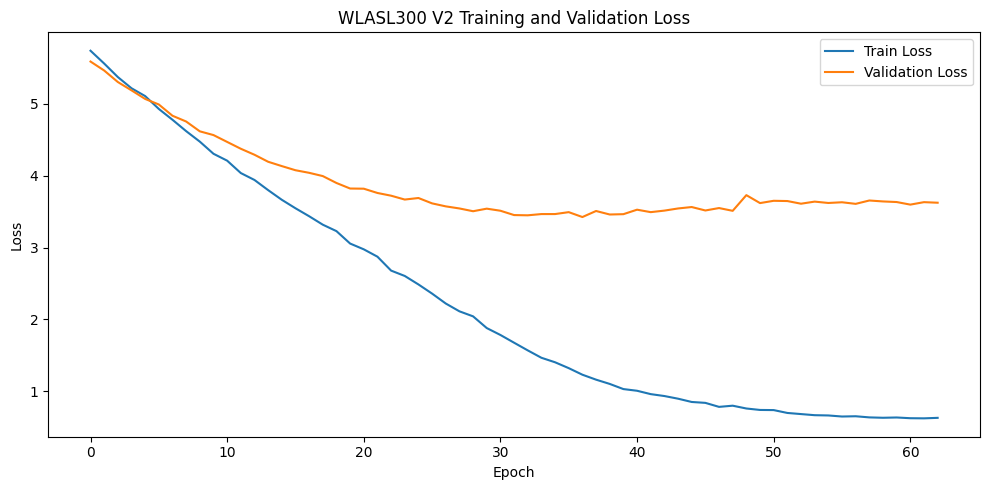

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["train_loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("WLASL300 V2 Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

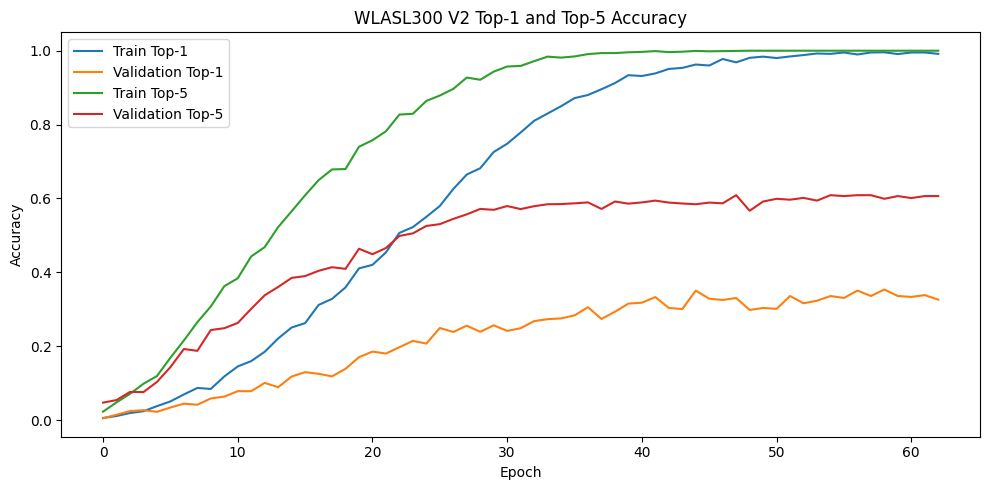

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["train_top1"], label="Train Top-1")
plt.plot(history_df["val_top1"], label="Validation Top-1")
plt.plot(history_df["train_top5"], label="Train Top-5")
plt.plot(history_df["val_top5"], label="Validation Top-5")
plt.title("WLASL300 V2 Top-1 and Top-5 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Test evaluation

In [16]:
checkpoint = torch.load(MODEL_PATH, map_location=device)

model = BiGRUAttentionV2(
    input_size=checkpoint.get("input_size", INPUT_SIZE),
    hidden_size=checkpoint.get("hidden_size", HIDDEN_SIZE),
    num_classes=checkpoint.get("num_classes", NUM_CLASSES),
    num_layers=checkpoint.get("num_layers", NUM_LAYERS),
    dropout=checkpoint.get("dropout", DROPOUT)
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded best V2 model from epoch:", checkpoint["epoch"])
print("Best validation F1:", checkpoint["best_val_f1"])
print("Best validation Top-5:", checkpoint["best_val_top5"])

Loaded best V2 model from epoch: 45
Best validation F1: 0.29069047619047617
Best validation Top-5: 0.5844474136829376


In [17]:
def collect_predictions(model, loader, device):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Collecting test predictions"):
            x = x.to(device)
            outputs = model(x)
            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(y.numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


y_true, y_pred, y_probs = collect_predictions(model, test_loader, device)

def top_k_accuracy_numpy(y_true, y_probs, k):
    correct = 0
    for true_label, prob in zip(y_true, y_probs):
        top_k_preds = np.argsort(prob)[-k:]
        if true_label in top_k_preds:
            correct += 1
    return correct / len(y_true)

test_top1 = accuracy_score(y_true, y_pred)
test_top3 = top_k_accuracy_numpy(y_true, y_probs, k=3)
test_top5 = top_k_accuracy_numpy(y_true, y_probs, k=5)
test_macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

print("=" * 80)
print("WLASL300 V2 Test Set Evaluation")
print("=" * 80)
print(f"Test Top-1 Accuracy: {test_top1:.4f}")
print(f"Test Top-3 Accuracy: {test_top3:.4f}")
print(f"Test Top-5 Accuracy: {test_top5:.4f}")
print(f"Test Macro F1: {test_macro_f1:.4f}")
print("=" * 80)

WLASL300 V2 Test Set Evaluation
Test Top-1 Accuracy: 0.2962
Test Top-3 Accuracy: 0.4684
Test Top-5 Accuracy: 0.5443
Test Macro F1: 0.2397


## 13. Save V2 result summary

In [18]:
result_df = pd.DataFrame([{
    "dataset": DATASET_NAME,
    "model": "BiGRU + Multi-Pooling Attention V2",
    "clean_samples": len(df),
    "classes": NUM_CLASSES,
    "input_shape": f"(60, {INPUT_SIZE})",
    "features": "keypoints + velocity + acceleration",
    "hidden_size": HIDDEN_SIZE,
    "num_layers": NUM_LAYERS,
    "dropout": DROPOUT,
    "best_val_f1": checkpoint["best_val_f1"],
    "best_val_top5": checkpoint["best_val_top5"],
    "checkpoint_epoch": checkpoint["epoch"],
    "test_top1_accuracy": test_top1,
    "test_top3_accuracy": test_top3,
    "test_top5_accuracy": test_top5,
    "test_macro_f1": test_macro_f1,
    "model_path": str(MODEL_PATH),
    "history_path": str(HISTORY_PATH),
    "norm_stats_path": str(NORM_STATS_PATH)
}])

result_df.to_csv(RESULT_FILE, index=False)

REPORT_RESULT_FILE = REPORT_DIR / f"{PREFIX}_bigru_attention_v2_result_summary.csv"
result_df.to_csv(REPORT_RESULT_FILE, index=False)

print("Saved V2 result summary to:")
print(RESULT_FILE)
print(REPORT_RESULT_FILE)

result_df

Saved V2 result summary to:
E:\Be_My_Ear\models\ASL\WLASL300\bigru_attention_v2_wlasl300_result_summary.csv
E:\Be_My_Ear\reports\phase1_wlasl300\wlasl300_bigru_attention_v2_result_summary.csv


,dataset,model,clean_samples,classes,input_shape,features,hidden_size,num_layers,dropout,best_val_f1,best_val_top5,checkpoint_epoch,test_top1_accuracy,test_top3_accuracy,test_top5_accuracy,test_macro_f1,model_path,history_path,norm_stats_path
0,WLASL300,BiGRU + Multi-Pooling Attention V2,2660,300,"(60, 774)",keypoints + velocity + acceleration,384,3,0.35,0.29069,0.584447,45,0.296203,0.468354,0.544304,0.239693,E:\Be_My_Ear\models\ASL\WLASL300\bigru_attenti...,E:\Be_My_Ear\models\ASL\WLASL300\bigru_attenti...,E:\Be_My_Ear\models\ASL\WLASL300\wlasl300_v2_t...


## 14. Confidence threshold analysis

In [19]:
if LABEL_MAP_FILE.exists():
    with open(LABEL_MAP_FILE, "r", encoding="utf-8") as f:
        label_map = json.load(f)
    id_to_gloss = {int(label_id): info["gloss"] for label_id, info in label_map.items()}
else:
    id_to_gloss = {}

prediction_records = []
test_df_reset = test_df.reset_index(drop=True)

for i in range(len(y_true)):
    true_id = int(y_true[i])
    pred_id = int(y_pred[i])
    confidence = float(y_probs[i][pred_id])
    top5_ids = np.argsort(y_probs[i])[-5:][::-1]

    prediction_records.append({
        "video_id": test_df_reset.iloc[i]["video_id"],
        "true_label_id": true_id,
        "true_gloss": id_to_gloss.get(true_id, str(true_id)),
        "predicted_label_id": pred_id,
        "predicted_gloss": id_to_gloss.get(pred_id, str(pred_id)),
        "confidence": confidence,
        "correct_top1": true_id == pred_id,
        "correct_top5": true_id in top5_ids,
        "top5_glosses": ", ".join([id_to_gloss.get(int(x), str(x)) for x in top5_ids])
    })

predictions_df = pd.DataFrame(prediction_records)

PREDICTIONS_FILE = REPORT_DIR / f"{PREFIX}_bigru_v2_test_predictions.csv"
predictions_df.to_csv(PREDICTIONS_FILE, index=False)

print("Saved V2 predictions to:", PREDICTIONS_FILE)
predictions_df.head()

Saved V2 predictions to: E:\Be_My_Ear\reports\phase1_wlasl300\wlasl300_bigru_v2_test_predictions.csv


,video_id,true_label_id,true_gloss,predicted_label_id,predicted_gloss,confidence,correct_top1,correct_top5,top5_glosses
0,10462,57,children,57,children,0.619303,True,True,"children, plan, order, chat, stay"
1,63204,284,white,177,like,0.415444,False,True,"like, fine, white, heart, cough"
2,35509,188,meet,232,run,0.574806,False,True,"run, first, meet, how, law"
3,65278,40,but,90,different,0.651455,False,True,"different, divorce, but, check, bar"
4,64281,296,yes,197,need,0.578396,False,True,"need, no, green, yes, pizza"


In [20]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

threshold_records = []

for threshold in thresholds:
    confident_df = predictions_df[predictions_df["confidence"] >= threshold]

    if len(confident_df) == 0:
        coverage = 0
        top1_at_threshold = np.nan
        top5_at_threshold = np.nan
    else:
        coverage = len(confident_df) / len(predictions_df)
        top1_at_threshold = confident_df["correct_top1"].mean()
        top5_at_threshold = confident_df["correct_top5"].mean()

    threshold_records.append({
        "confidence_threshold": threshold,
        "coverage": coverage,
        "top1_accuracy_on_confident_samples": top1_at_threshold,
        "top5_accuracy_on_confident_samples": top5_at_threshold,
        "num_confident_samples": len(confident_df)
    })

threshold_df = pd.DataFrame(threshold_records)

THRESHOLD_FILE = REPORT_DIR / f"{PREFIX}_bigru_v2_confidence_threshold_analysis.csv"
threshold_df.to_csv(THRESHOLD_FILE, index=False)

print("Saved V2 confidence threshold analysis to:", THRESHOLD_FILE)
threshold_df

Saved V2 confidence threshold analysis to: E:\Be_My_Ear\reports\phase1_wlasl300\wlasl300_bigru_v2_confidence_threshold_analysis.csv


,confidence_threshold,coverage,top1_accuracy_on_confident_samples,top5_accuracy_on_confident_samples,num_confident_samples
0,0.2,0.926582,0.316940,0.565574,366
1,0.3,0.734177,0.368966,0.620690,290
2,0.4,0.600000,0.400844,0.641350,237
3,0.5,0.460759,0.467033,0.675824,182
4,0.6,0.356962,0.531915,0.723404,141
5,0.7,0.258228,0.607843,0.784314,102
6,0.8,0.174684,0.594203,0.782609,69
7,0.9,0.075949,0.766667,0.933333,30


## 15. Compare V1 vs V2

In [21]:
possible_v1_files = [
    MODEL_DIR / f"bigru_attention_{PREFIX}_result_summary.csv",
    REPORT_DIR / f"{PREFIX}_overall_metrics.csv"
]

v1_result = None
v1_source = None

for file in possible_v1_files:
    if file.exists():
        temp_df = pd.read_csv(file)
        if len(temp_df) > 0:
            v1_result = temp_df.iloc[0].to_dict()
            v1_source = file
            break

comparison_rows = []

if v1_result is not None:
    comparison_rows.append({
        "version": "V1",
        "model": v1_result.get("model", "BiGRU + Temporal Attention"),
        "test_top1_accuracy": float(v1_result.get("test_top1_accuracy", np.nan)),
        "test_top3_accuracy": float(v1_result.get("test_top3_accuracy", np.nan)),
        "test_top5_accuracy": float(v1_result.get("test_top5_accuracy", np.nan)),
        "test_macro_f1": float(v1_result.get("test_macro_f1", np.nan)),
        "best_val_f1": float(v1_result.get("best_val_f1", np.nan)),
        "best_val_top5": float(v1_result.get("best_val_top5", np.nan)),
        "source": str(v1_source)
    })

comparison_rows.append({
    "version": "V2",
    "model": "BiGRU + Multi-Pooling Attention V2",
    "test_top1_accuracy": test_top1,
    "test_top3_accuracy": test_top3,
    "test_top5_accuracy": test_top5,
    "test_macro_f1": test_macro_f1,
    "best_val_f1": checkpoint["best_val_f1"],
    "best_val_top5": checkpoint["best_val_top5"],
    "source": str(RESULT_FILE)
})

comparison_df = pd.DataFrame(comparison_rows)

COMPARISON_FILE = REPORT_DIR / f"{PREFIX}_v1_vs_v2_comparison.csv"
comparison_df.to_csv(COMPARISON_FILE, index=False)

print("Saved V1 vs V2 comparison to:", COMPARISON_FILE)
comparison_df

Saved V1 vs V2 comparison to: E:\Be_My_Ear\reports\phase1_wlasl300\wlasl300_v1_vs_v2_comparison.csv


,version,model,test_top1_accuracy,test_top3_accuracy,test_top5_accuracy,test_macro_f1,best_val_f1,best_val_top5,source
0,V1,BiGRU + Temporal Attention,0.359484,0.582823,0.673733,0.296921,0.35554,0.723995,E:\Be_My_Ear\models\ASL\WLASL300\bigru_attenti...
1,V2,BiGRU + Multi-Pooling Attention V2,0.296203,0.468354,0.544304,0.239693,0.29069,0.584447,E:\Be_My_Ear\models\ASL\WLASL300\bigru_attenti...


In [22]:
if len(comparison_df) >= 2:
    v1 = comparison_df[comparison_df["version"] == "V1"].iloc[0]
    v2 = comparison_df[comparison_df["version"] == "V2"].iloc[0]

    print("WLASL300 V1 vs V2 improvement")
    print("-----------------------------")
    print(f"Top-1 improvement: {v2['test_top1_accuracy'] - v1['test_top1_accuracy']:.4f}")
    print(f"Top-3 improvement: {v2['test_top3_accuracy'] - v1['test_top3_accuracy']:.4f}")
    print(f"Top-5 improvement: {v2['test_top5_accuracy'] - v1['test_top5_accuracy']:.4f}")
    print(f"Macro F1 improvement: {v2['test_macro_f1'] - v1['test_macro_f1']:.4f}")
else:
    print("No V1 result file found. V2 result saved, but comparison skipped.")

WLASL300 V1 vs V2 improvement
-----------------------------
Top-1 improvement: -0.0633
Top-3 improvement: -0.1145
Top-5 improvement: -0.1294
Macro F1 improvement: -0.0572


## Final decision guide

Use this result to decide the next move:

```text
If V2 improves Top-1 and Macro F1:
    use V2 architecture for WLASL1000

If V2 is similar or worse:
    keep V1 and test Transformer on WLASL300
```

In [23]:
print("Final WLASL300 V2 summary")
print("-------------------------")
print(f"Dataset: {DATASET_NAME}")
print(f"Clean samples: {len(df)}")
print(f"Classes: {NUM_CLASSES}")
print("Model: BiGRU + Multi-Pooling Attention V2")
print(f"Input shape: (60, {INPUT_SIZE})")
print("Features: keypoints + velocity + acceleration")
print(f"Best validation F1: {checkpoint['best_val_f1']:.4f}")
print(f"Best validation Top-5: {checkpoint['best_val_top5']:.4f}")
print(f"Test Top-1 Accuracy: {test_top1:.4f}")
print(f"Test Top-3 Accuracy: {test_top3:.4f}")
print(f"Test Top-5 Accuracy: {test_top5:.4f}")
print(f"Test Macro F1: {test_macro_f1:.4f}")
print()
print("Saved files:")
print("-", MODEL_PATH)
print("-", HISTORY_PATH)
print("-", RESULT_FILE)
print("-", REPORT_RESULT_FILE)
print("-", PREDICTIONS_FILE)
print("-", THRESHOLD_FILE)
print("-", COMPARISON_FILE)

Final WLASL300 V2 summary
-------------------------
Dataset: WLASL300
Clean samples: 2660
Classes: 300
Model: BiGRU + Multi-Pooling Attention V2
Input shape: (60, 774)
Features: keypoints + velocity + acceleration
Best validation F1: 0.2907
Best validation Top-5: 0.5844
Test Top-1 Accuracy: 0.2962
Test Top-3 Accuracy: 0.4684
Test Top-5 Accuracy: 0.5443
Test Macro F1: 0.2397

Saved files:
- E:\Be_My_Ear\models\ASL\WLASL300\bigru_attention_v2_wlasl300.pt
- E:\Be_My_Ear\models\ASL\WLASL300\bigru_attention_v2_wlasl300_history.csv
- E:\Be_My_Ear\models\ASL\WLASL300\bigru_attention_v2_wlasl300_result_summary.csv
- E:\Be_My_Ear\reports\phase1_wlasl300\wlasl300_bigru_attention_v2_result_summary.csv
- E:\Be_My_Ear\reports\phase1_wlasl300\wlasl300_bigru_v2_test_predictions.csv
- E:\Be_My_Ear\reports\phase1_wlasl300\wlasl300_bigru_v2_confidence_threshold_analysis.csv
- E:\Be_My_Ear\reports\phase1_wlasl300\wlasl300_v1_vs_v2_comparison.csv


## WLASL300 Model Selection

Two BiGRU-based models were tested on WLASL300. The original BiGRU + Temporal Attention model outperformed the larger V2 model across all major metrics.

The V1 model achieved 35.95% Top-1 accuracy, 58.28% Top-3 accuracy, 67.37% Top-5 accuracy, and 29.69% Macro F1. The V2 model, which added acceleration features, deeper GRU layers, and multi-pooling, performed worse with 29.62% Top-1 accuracy and 23.97% Macro F1.

This suggests that the larger V2 model was too complex for the current WLASL300 data size. Therefore, the selected architecture for scaling to WLASL1000 is the original BiGRU + Temporal Attention model with keypoint and velocity features.